In [1]:
# import emcee
import pandas as pd

In [43]:
data = pd.read_csv('pow_shear_pos+flux_mcmc.dat', delim_whitespace = True, names=['chi2', '$z_{l}$', 'x', 'y', 'e', 'pa', '$r_{ein}$', 'PWI', '$z_{sl}$', '$\gamma_{ext}$', '$\\theta_{ext}$'])
data

,chi2,$z_{l}$,x,y,e,pa,$r_{ein}$,PWI,$z_{sl}$,$\gamma_{ext}$,$\theta_{ext}$
0,2.492555,1.000000,-0.264524,0.347464,0.106552,-48.66229,0.443166,1.850725,1.000000,0.042332,-141.9250
1,9.470881,0.949882,-0.263680,0.347966,0.105258,-48.66992,0.443344,1.851613,0.949882,0.042286,-141.9407
2,15.051650,0.929080,-0.263020,0.347995,0.105544,-48.67612,0.443228,1.850472,0.929080,0.042675,-141.9411
3,6.575180,0.861107,-0.263848,0.347843,0.105369,-48.67222,0.442851,1.851160,0.861107,0.042179,-141.9348
4,12.976410,0.806692,-0.263545,0.347459,0.105231,-48.69188,0.442760,1.849694,0.806692,0.042130,-141.9389
...,...,...,...,...,...,...,...,...,...,...,...
19014,7.996358,1.160270,-0.251343,0.357866,0.138737,-46.12464,0.451372,1.870088,1.160270,0.056943,-142.5843
19015,8.810983,1.152558,-0.251467,0.358429,0.140401,-46.13053,0.451940,1.869339,1.152558,0.057824,-142.5861
19016,10.375030,1.232077,-0.250719,0.357813,0.141188,-46.13201,0.452227,1.869202,1.232077,0.057453,-142.5721
19017,13.626950,1.225222,-0.250374,0.358415,0.141238,-46.13119,0.451557,1.868301,1.225222,0.058058,-142.5705


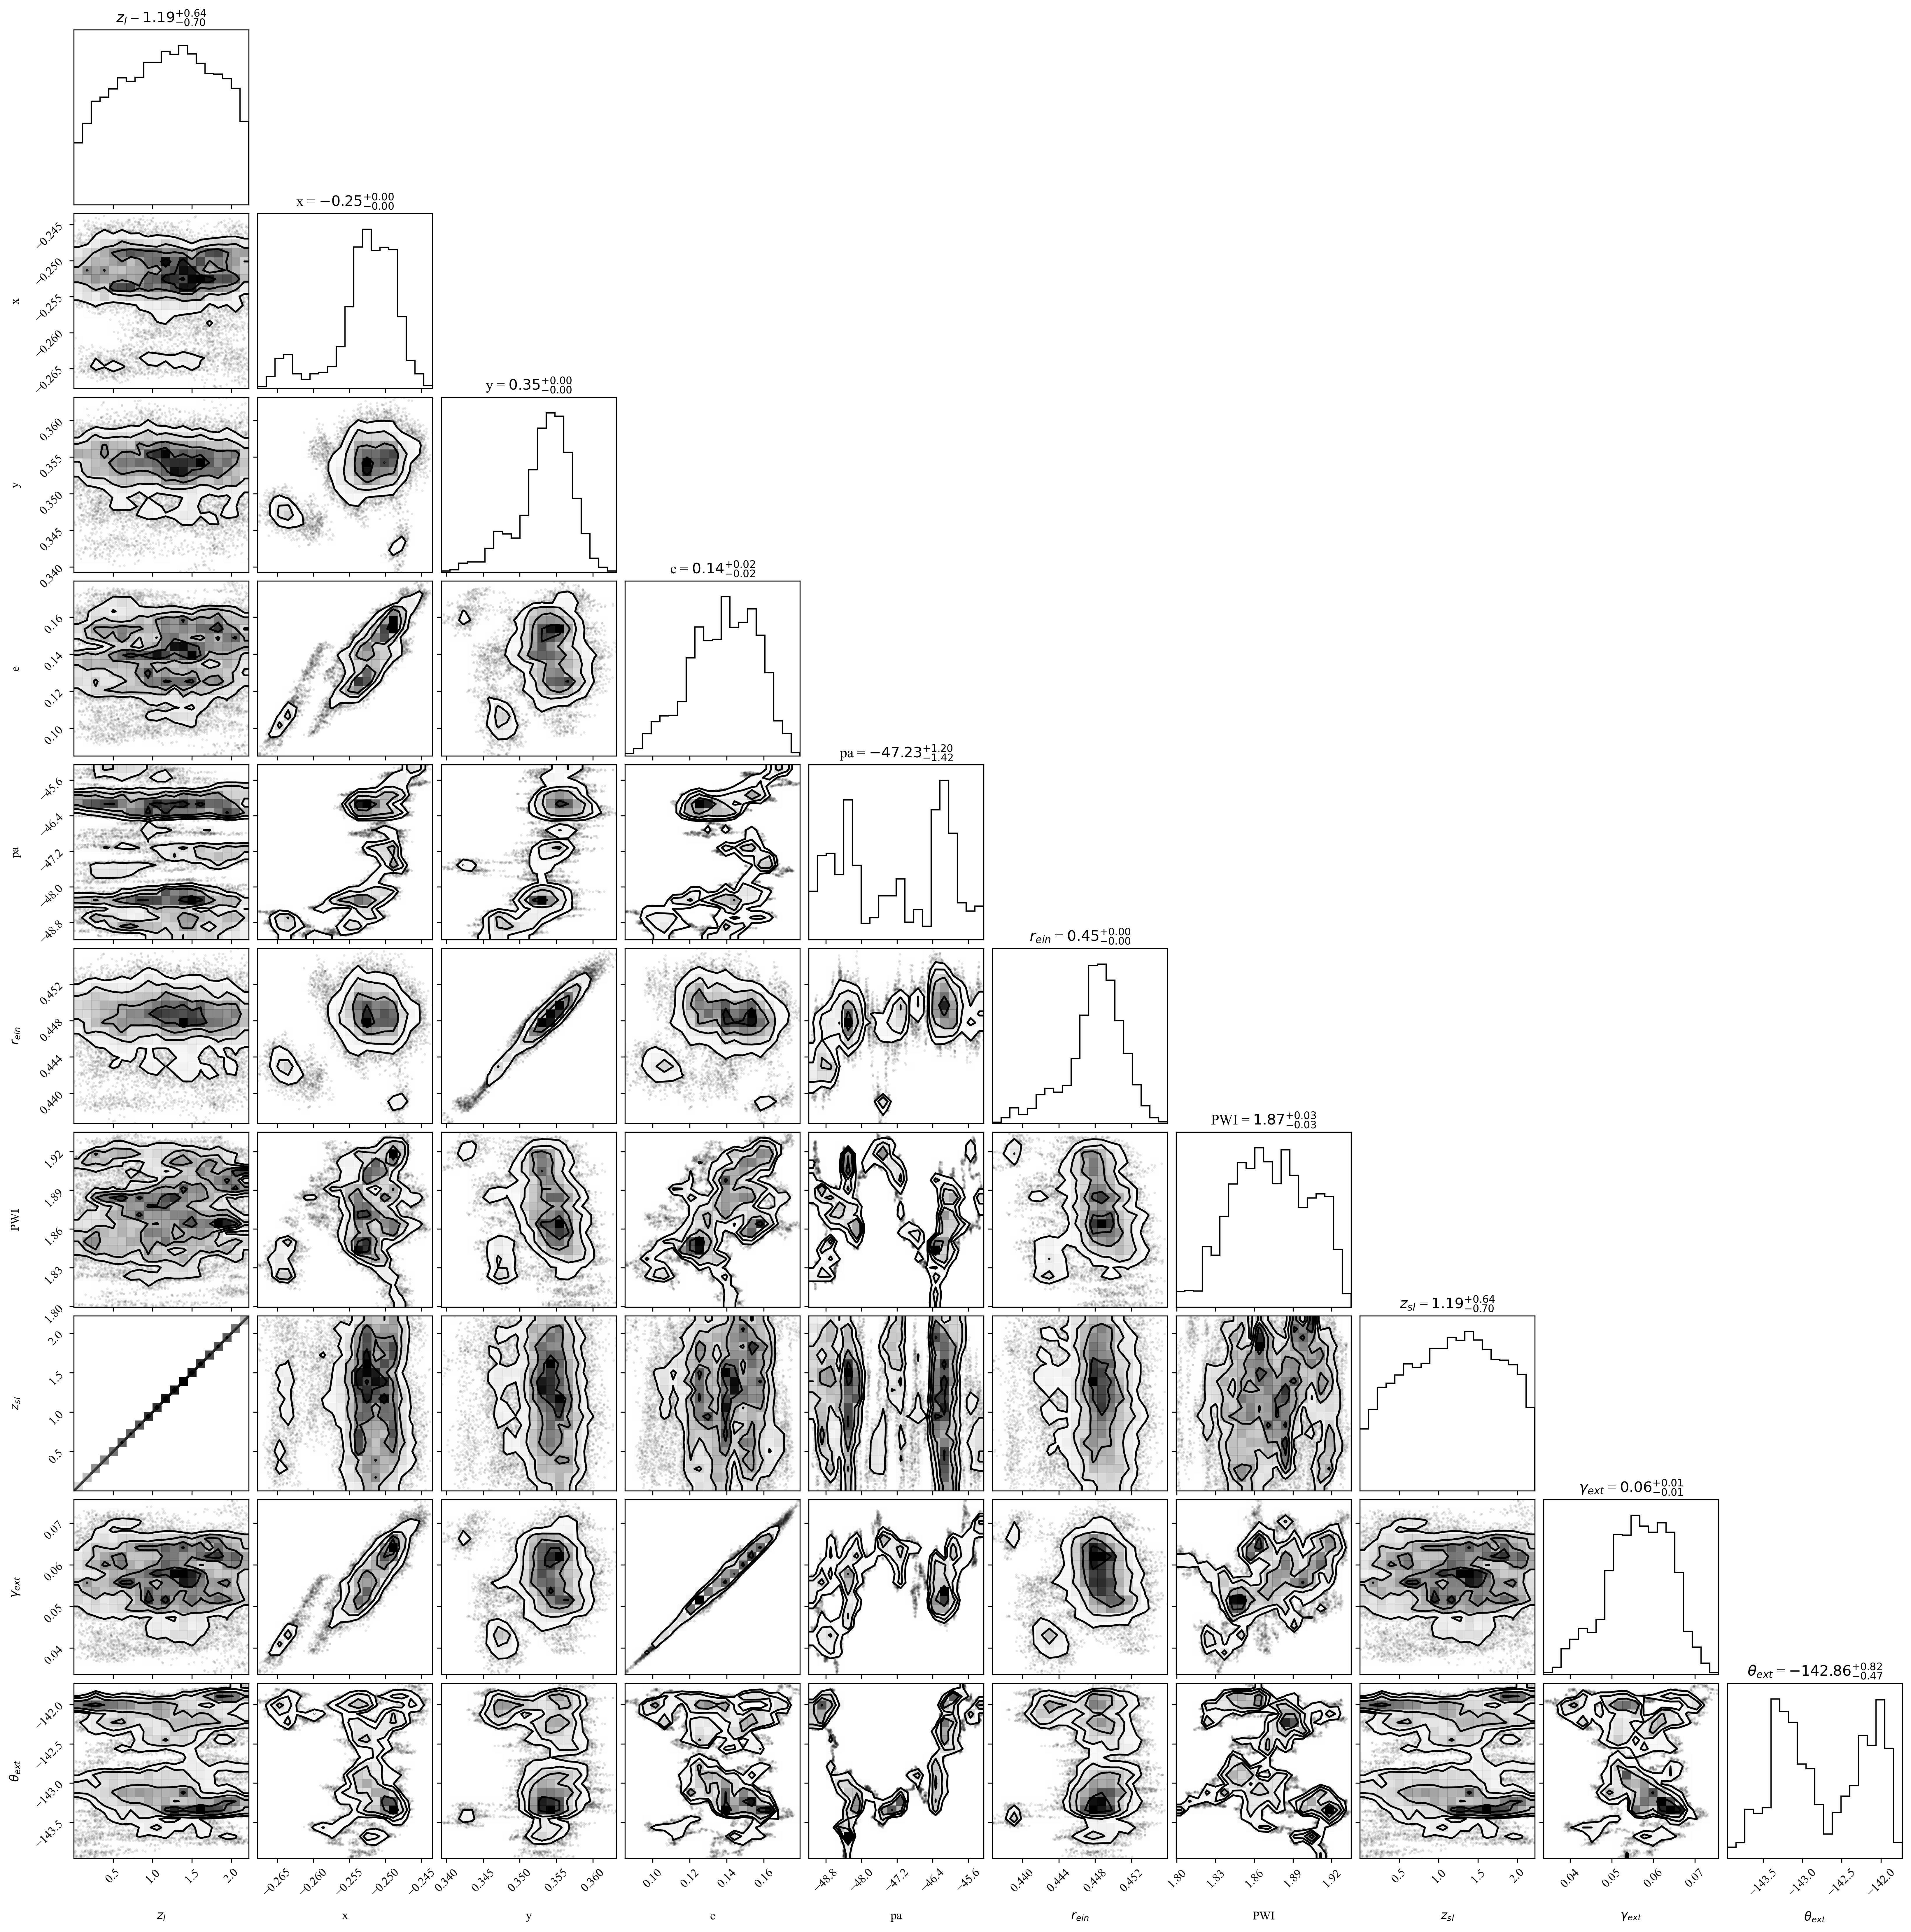

In [44]:
# Corner plot
import corner
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
# Select the parameters to plot (excluding chi2)
params = data.columns[1:]  # Exclude the first column (chi2)
# Create the corner plot
fig = corner.corner(data[params], labels=params, show_titles=True)
plt.show()

In [73]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Times New Roman",
    "text.latex.preamble": (
        r"\boldmath"                       # Makes math symbols/numbers bold
        r"\renewcommand{\seriesdefault}{b}" # Makes normal text bold globally (Computer Modern)
    )
})

Text(0.5, 1.0, '$z_{LENS} = 1.19^{+0.64}_{-0.70}$')

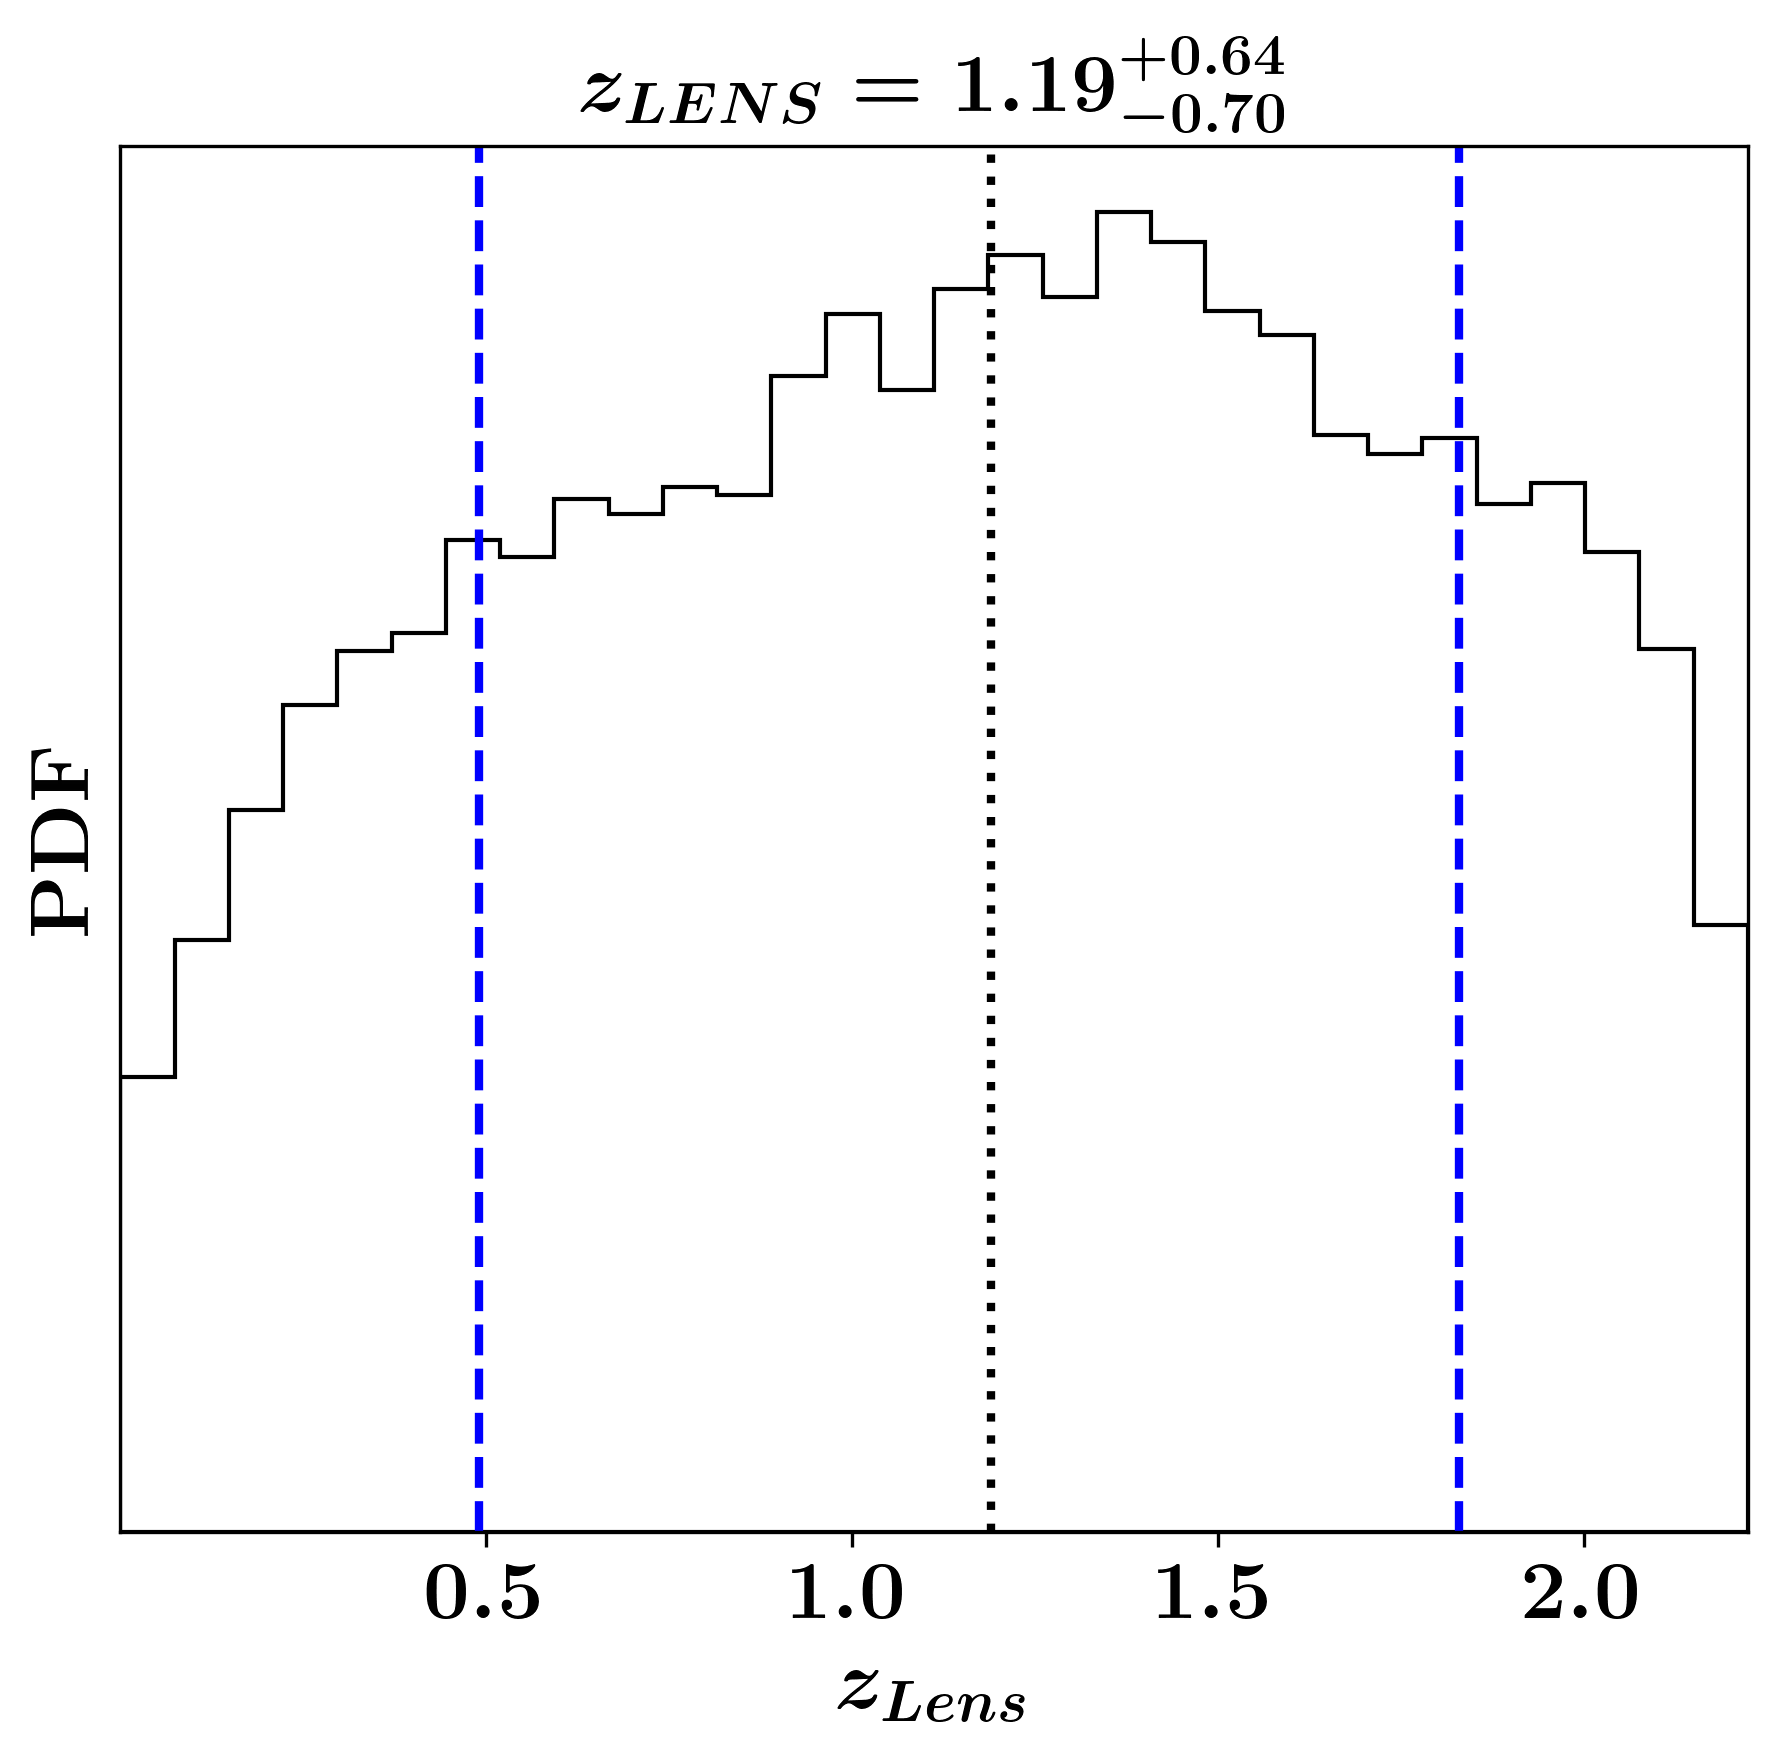

In [74]:
# Plot just the $z_{l}$ histogram
mean_zl = data['$z_{l}$'].mean()
upper_zl = mean_zl + data['$z_{l}$'].std()
lower_zl = mean_zl - data['$z_{l}$'].std()
plt.figure(figsize=(7, 6))
# Histogram with no lines between bins, white fill, and black edges
plt.hist(data['$z_{l}$'], bins=30, density=True, color='white', edgecolor='black', histtype='stepfilled')
# No Y axis labels or ticks
plt.yticks([])
# Increase x ticks to 14pt font size
plt.xticks([0.0, 0.5, 1.0, 1.5, 2.0], fontsize=20, fontweight='bold')
plt.xlabel('$z_{Lens}$', fontsize=20, fontweight='bold')
plt.ylabel('PDF', fontsize=20, fontweight='bold')
plt.xlim(data['$z_{l}$'].min(), data['$z_{l}$'].max())
# Add dotted line at 1.19+0.64 and 1.19-0.70
plt.axvline(x=1.19, color='black', linestyle=':', linewidth=2)
plt.axvline(x=1.19+0.64, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=1.19-0.70, color='blue', linestyle='--', linewidth=2)
# Title in same format as corner plot
plt.title('$z_{LENS} = 1.19^{+0.64}_{-0.70}$', fontsize=20, fontweight='bold', pad=10)